# Reinforcement Learning Individual Assignment
## Configuration Generalization Analysis

**Goal:** Evaluate how well agents trained on a specific TFB configuration
(`height=15, width=20, pipe_gap=4`) perform when the environment parameters change.

We test both the **GLIE Monte-Carlo** and **SARSA(λ)** agents across different:
- **Heights** (screen size)
- **Widths** (distance between pipes)
- **Pipe gaps** (difficulty)

In [1]:
import os, sys
import gymnasium as gym
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm import tqdm
import pickle
from pathlib import Path

import text_flappy_bird_gym

## 1. Agent Definitions & Loading

We redefine both agent classes here so the notebook is self-contained, then load the trained Q-tables from disk.

In [2]:
class GLIEMCAgent:
    """GLIE Monte-Carlo Control agent."""
    def __init__(self, n_actions=2, **kwargs):
        self.n_actions = n_actions
        self.Q = defaultdict(float)
        self.N = defaultdict(int)

    def greedy_action(self, state: tuple) -> int:
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)


class SarsaLambdaAgent:
    """SARSA(lambda) agent with eligibility traces."""
    def __init__(self, n_actions=2, **kwargs):
        self.n_actions = n_actions
        self.Q = defaultdict(float)

    def greedy_action(self, state: tuple) -> int:
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)

In [3]:
results_root = Path.cwd().parent / 'results'

# Load MC agent
mc_agent = GLIEMCAgent(n_actions=2)
mc_path = results_root / 'MC' / 'mc_agent.pkl'
with open(mc_path, 'rb') as f:
    data = pickle.load(f)
mc_agent.Q = defaultdict(float, data['Q'])
mc_agent.N = defaultdict(int, data['N'])
print(f"MC agent loaded: {len(mc_agent.Q)} Q-entries")

# Load SARSA agent
sarsa_agent = SarsaLambdaAgent(n_actions=2)
sarsa_path = results_root / 'SARSA' / 'sarsa_lambda_agent.pkl'
with open(sarsa_path, 'rb') as f:
    data = pickle.load(f)
sarsa_agent.Q = defaultdict(float, data['Q'])
print(f"SARSA agent loaded: {len(sarsa_agent.Q)} Q-entries")

MC agent loaded: 540 Q-entries
SARSA agent loaded: 546 Q-entries


## 2. Evaluation Utility

Evaluate a trained agent (greedy) on any TFB configuration.
Each episode is capped at `max_steps` to avoid infinite runs from well-trained agents.

In [4]:
TRAIN_CONFIG = dict(height=15, width=20, pipe_gap=4)
N_EVAL = 500
MAX_STEPS = 5000

def evaluate(agent, env_kwargs, n_episodes=N_EVAL, max_steps=MAX_STEPS):
    """Evaluate agent greedily on a given TFB configuration."""
    env = gym.make('TextFlappyBird-v0', **env_kwargs)
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        state = tuple(obs)
        total = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = agent.greedy_action(state)
            obs, reward, done, _, _ = env.step(action)
            state = tuple(obs)
            total += reward
            steps += 1
        rewards.append(total)
    env.close()
    return rewards

## 3. Define Test Configurations

We vary one parameter at a time while keeping the other two at their training values. This isolates the effect of each parameter on generalization.

| Sweep | Values tested | Training value |
|---|---|---|
| `pipe_gap` | 2, 3, 4, 5, 6 | 4 |
| `height` | 10, 12, 15, 18, 20 | 15 |
| `width` | 15, 18, 20, 25, 30 | 20 |

In [5]:
sweeps = {
    "pipe_gap": {
        "values": [2, 3, 4, 5, 6],
        "base": {k: v for k, v in TRAIN_CONFIG.items()},
        "param": "pipe_gap",
    },
    "height": {
        "values": [10, 12, 15, 18, 20],
        "base": {k: v for k, v in TRAIN_CONFIG.items()},
        "param": "height",
    },
    "width": {
        "values": [15, 18, 20, 25, 30],
        "base": {k: v for k, v in TRAIN_CONFIG.items()},
        "param": "width",
    },
}

agents = {"MC": mc_agent, "SARSA(\u03bb)": sarsa_agent}

print("Configurations to evaluate:")
for sweep_name, sweep in sweeps.items():
    print(f"  {sweep_name}: {sweep['values']}")

Configurations to evaluate:
  pipe_gap: [2, 3, 4, 5, 6]
  height: [10, 12, 15, 18, 20]
  width: [15, 18, 20, 25, 30]


## 4. Run Evaluation Across Configurations

For each sweep we evaluate both agents on every configuration and collect the mean and std of greedy rewards.

In [6]:
results = []

for sweep_name, sweep in sweeps.items():
    param = sweep["param"]
    for val in tqdm(sweep["values"], desc=f"Sweep: {sweep_name}"):
        env_kwargs = {**sweep["base"], param: val}
        for agent_name, agent in agents.items():
            rews = evaluate(agent, env_kwargs)
            results.append({
                "sweep": sweep_name,
                "param_value": val,
                "agent": agent_name,
                "mean_reward": np.mean(rews),
                "std_reward": np.std(rews),
                "is_train": (val == TRAIN_CONFIG[param]),
                "config": env_kwargs,
            })

df = pd.DataFrame(results)
print(f"Total evaluations: {len(df)}")
df.head(10)

Sweep: width: 100%|██████████| 5/5 [01:24<00:00, 16.98s/it]

Total evaluations: 30


,sweep,param_value,agent,mean_reward,std_reward,is_train,config
0,pipe_gap,2,MC,30.228,25.423611,False,"{'height': 15, 'width': 20, 'pipe_gap': 2}"
1,pipe_gap,2,SARSA(λ),16.666,6.721194,False,"{'height': 15, 'width': 20, 'pipe_gap': 2}"
2,pipe_gap,3,MC,31.012,21.806876,False,"{'height': 15, 'width': 20, 'pipe_gap': 3}"
3,pipe_gap,3,SARSA(λ),30.466,17.697481,False,"{'height': 15, 'width': 20, 'pipe_gap': 3}"
4,pipe_gap,4,MC,2344.288,1718.022439,True,"{'height': 15, 'width': 20, 'pipe_gap': 4}"
5,pipe_gap,4,SARSA(λ),3761.590,1797.885236,True,"{'height': 15, 'width': 20, 'pipe_gap': 4}"
6,pipe_gap,5,MC,2035.024,1642.461599,False,"{'height': 15, 'width': 20, 'pipe_gap': 5}"
7,pipe_gap,5,SARSA(λ),4443.660,1303.489933,False,"{'height': 15, 'width': 20, 'pipe_gap': 5}"
8,pipe_gap,6,MC,1361.148,1146.877034,False,"{'height': 15, 'width': 20, 'pipe_gap': 6}"
9,pipe_gap,6,SARSA(λ),5000.000,0.000000,False,"{'height': 15, 'width': 20, 'pipe_gap': 6}"


## 5. Visualization

For each swept parameter we plot the mean greedy reward (with error bars) for both agents. The training configuration is highlighted with a dashed vertical line.

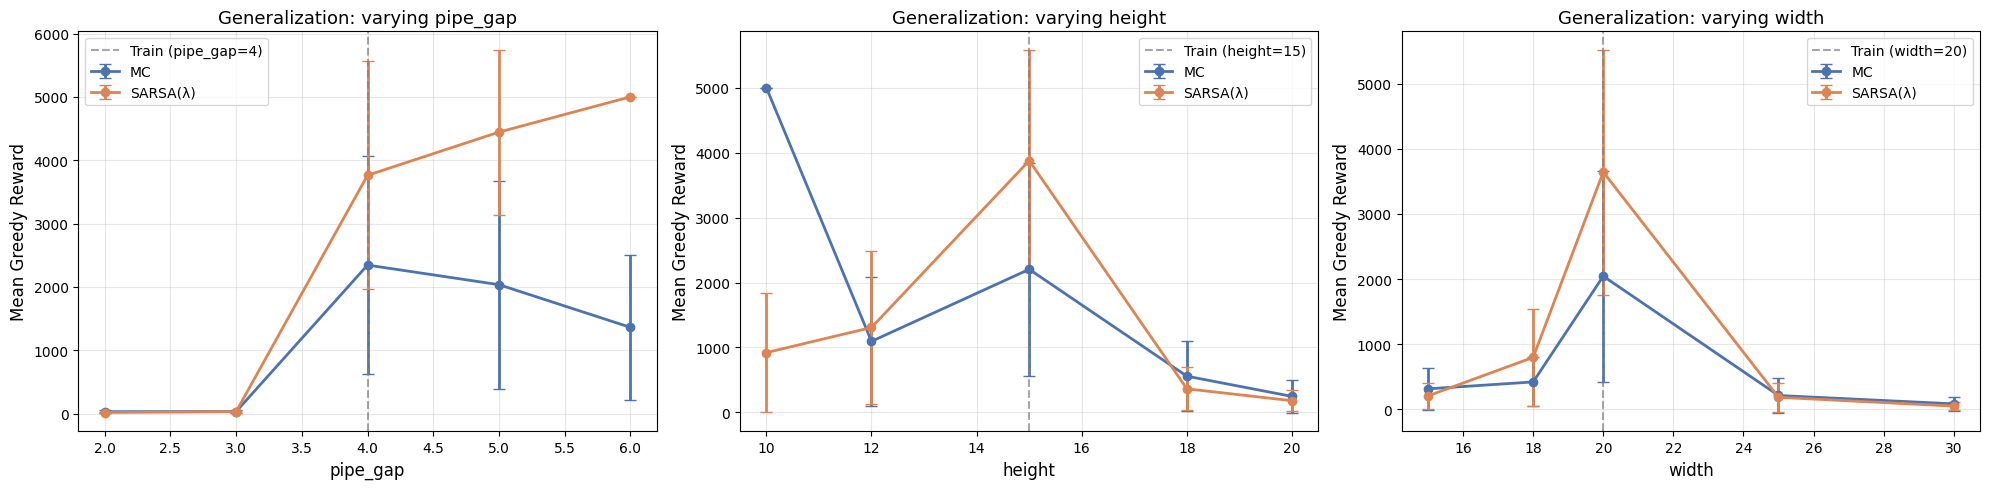

In [7]:
agent_colors = {"MC": "#4C72B0", "SARSA(\u03bb)": "#DD8452"}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (sweep_name, sweep) in zip(axes, sweeps.items()):
    param = sweep["param"]
    train_val = TRAIN_CONFIG[param]
    sub = df[df["sweep"] == sweep_name]

    for agent_name, color in agent_colors.items():
        agent_data = sub[sub["agent"] == agent_name].sort_values("param_value")
        ax.errorbar(
            agent_data["param_value"], agent_data["mean_reward"],
            yerr=agent_data["std_reward"],
            marker='o', capsize=4, label=agent_name, color=color, linewidth=2,
        )

    ax.axvline(train_val, color='grey', linestyle='--', alpha=0.7, label=f"Train ({param}={train_val})")
    ax.set_xlabel(param, fontsize=12)
    ax.set_ylabel("Mean Greedy Reward", fontsize=12)
    ax.set_title(f"Generalization: varying {param}", fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_root / "Configurations/generalization.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary Table

Percentage change in mean reward relative to the training configuration for each agent.

In [8]:
rows = []
for sweep_name, sweep in sweeps.items():
    param = sweep["param"]
    train_val = TRAIN_CONFIG[param]
    sub = df[df["sweep"] == sweep_name]

    for agent_name in agents:
        agent_sub = sub[sub["agent"] == agent_name]
        baseline = agent_sub[agent_sub["param_value"] == train_val]["mean_reward"].values[0]
        for _, row in agent_sub.iterrows():
            pct = ((row["mean_reward"] - baseline) / abs(baseline)) * 100 if baseline != 0 else 0
            rows.append({
                "Parameter": param,
                "Value": row["param_value"],
                "Agent": agent_name,
                "Mean Reward": f"{row['mean_reward']:.1f}",
                "Std": f"{row['std_reward']:.1f}",
                "% vs Train": f"{pct:+.1f}%",
                "Is Train Config": "\u2713" if row["is_train"] else "",
            })

summary = pd.DataFrame(rows)
summary

,Parameter,Value,Agent,Mean Reward,Std,% vs Train,Is Train Config
0,pipe_gap,2,MC,30.2,25.4,-98.7%,
1,pipe_gap,3,MC,31.0,21.8,-98.7%,
2,pipe_gap,4,MC,2344.3,1718.0,+0.0%,✓
3,pipe_gap,5,MC,2035.0,1642.5,-13.2%,
4,pipe_gap,6,MC,1361.1,1146.9,-41.9%,
5,pipe_gap,2,SARSA(λ),16.7,6.7,-99.6%,
6,pipe_gap,3,SARSA(λ),30.5,17.7,-99.2%,
7,pipe_gap,4,SARSA(λ),3761.6,1797.9,+0.0%,✓
8,pipe_gap,5,SARSA(λ),4443.7,1303.5,+18.1%,
9,pipe_gap,6,SARSA(λ),5000.0,0.0,+32.9%,


## 7. Heatmap: Pipe Gap vs Height

Evaluate both agents on a 2D grid of `pipe_gap` x `height` (with `width` fixed at 20) to visualize how difficulty interacts across two parameters simultaneously.

Heights: 100%|██████████| 5/5 [02:27<00:00, 29.59s/it]


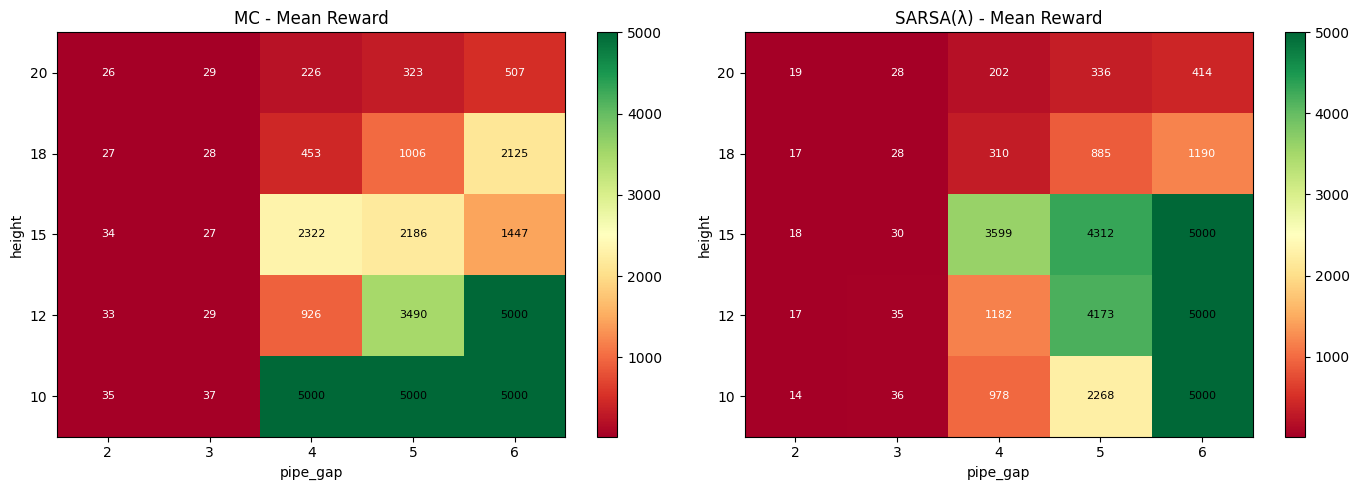

In [9]:
gaps = [2, 3, 4, 5, 6]
heights = [10, 12, 15, 18, 20]

heatmap_results = {name: np.zeros((len(heights), len(gaps))) for name in agents}

for i, h in enumerate(tqdm(heights, desc="Heights")):
    for j, g in enumerate(gaps):
        cfg = dict(height=h, width=20, pipe_gap=g)
        for agent_name, agent in agents.items():
            rews = evaluate(agent, cfg, n_episodes=100)
            heatmap_results[agent_name][i, j] = np.mean(rews)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (agent_name, mat) in zip(axes, heatmap_results.items()):
    im = ax.imshow(mat, aspect='auto', origin='lower', cmap='RdYlGn')
    ax.set_xticks(range(len(gaps)))
    ax.set_xticklabels(gaps)
    ax.set_yticks(range(len(heights)))
    ax.set_yticklabels(heights)
    ax.set_xlabel("pipe_gap")
    ax.set_ylabel("height")
    ax.set_title(f"{agent_name} - Mean Reward")
    # Annotate cells
    for i in range(len(heights)):
        for j in range(len(gaps)):
            ax.text(j, i, f"{mat[i, j]:.0f}", ha='center', va='center', fontsize=8,
                    color='black' if mat[i, j] > mat.mean() else 'white')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(results_root / "Configurations/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()